### ATIVIDADE 2 — Projeto RFM com Dataset Olist

#### Passo 1 — Carregar e juntar as tabelas do Olist

In [1]:
import sys
import os
import shutil
import kagglehub

base_dir = os.getcwd()
destino = os.path.join(base_dir, "dataset")

os.makedirs(destino, exist_ok=True)

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

shutil.copytree(path, destino, dirs_exist_ok=True)

print("Download concluído!")

print("\nDataset copiado para:")
print(destino)

c:\Users\layss\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download concluído!

Dataset copiado para:
c:\UTFPR\Inteligencia_artificial\Atividades_IA\atvd02\dataset


In [2]:
import os

print("Arquivos disponíveis:")
for arq in os.listdir(path):
    print(" ", arq)

Arquivos disponíveis:
  olist_customers_dataset.csv
  olist_geolocation_dataset.csv
  olist_orders_dataset.csv
  olist_order_items_dataset.csv
  olist_order_payments_dataset.csv
  olist_order_reviews_dataset.csv
  olist_products_dataset.csv
  olist_sellers_dataset.csv
  product_category_name_translation.csv


In [3]:
import pandas as pd
import numpy as np

PASTA_OLIST = path

orders    = pd.read_csv(os.path.join(PASTA_OLIST, "olist_orders_dataset.csv"))
payments  = pd.read_csv(os.path.join(PASTA_OLIST, "olist_order_payments_dataset.csv"))
customers = pd.read_csv(os.path.join(PASTA_OLIST, "olist_customers_dataset.csv"))

print("Tabelas carregadas!")
print(f"  orders:    {orders.shape}")
print(f"  payments:  {payments.shape}")
print(f"  customers: {customers.shape}")

Tabelas carregadas!
  orders:    (99441, 8)
  payments:  (103886, 5)
  customers: (99441, 5)


In [4]:
orders_ok = orders[orders['order_status'] == 'delivered'].copy()

orders_ok['order_purchase_timestamp'] = pd.to_datetime(
    orders_ok['order_purchase_timestamp']
)

orders_ok = orders_ok.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id', how='left'
)

valor_pedido = (payments
                .groupby('order_id')['payment_value']
                .sum()
                .reset_index()
                .rename(columns={'payment_value': 'valor_total'}))

df = orders_ok.merge(valor_pedido, on='order_id', how='left')

df = df.dropna(subset=['valor_total', 'customer_unique_id'])
df = df[df['valor_total'] > 0]

print(f"Pedidos após limpeza: {df.shape[0]}")
print(f"Clientes únicos:      {df['customer_unique_id'].nunique()}")
print(f"\nPrimeiras linhas:")
print(df[['customer_unique_id','order_purchase_timestamp','valor_total']].head())

Pedidos após limpeza: 96477
Clientes únicos:      93357

Primeiras linhas:
                 customer_unique_id order_purchase_timestamp  valor_total
0  7c396fd4830fd04220f754e42b4e5bff      2017-10-02 10:56:33        38.71
1  af07308b275d755c9edb36a90c618231      2018-07-24 20:41:37       141.46
2  3a653a41f6f9fc3d2a113cf8398680e8      2018-08-08 08:38:49       179.12
3  7c142cf63193a1473d2e66489a9ae977      2017-11-18 19:28:06        72.20
4  72632f0f9dd73dfee390c9b22eb56dd6      2018-02-13 21:18:39        28.62


#### Passo 2 — Calcular as métricas RFM

In [5]:
DATA_REF = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Data de referência: {DATA_REF.date()}")

# Calcular R, F, M por cliente
rfm = (df.groupby('customer_unique_id')
         .agg(
             Recencia   = ('order_purchase_timestamp',
                           lambda x: (DATA_REF - x.max()).days),
             Frequencia = ('order_id', 'nunique'),
             Monetario  = ('valor_total', 'sum')
         )
         .reset_index())

print(f"\nTabela RFM gerada: {rfm.shape}")
print(rfm.describe().round(2))

Data de referência: 2018-08-30

Tabela RFM gerada: (93357, 4)
       Recencia  Frequencia  Monetario
count  93357.00    93357.00   93357.00
mean     237.94        1.03     165.20
std      152.58        0.21     226.31
min        1.00        1.00       9.59
25%      114.00        1.00      63.06
50%      219.00        1.00     107.78
75%      346.00        1.00     182.56
max      695.00       15.00   13664.08


#### Passo 3 — Distribuições RFM (antes da transformação)

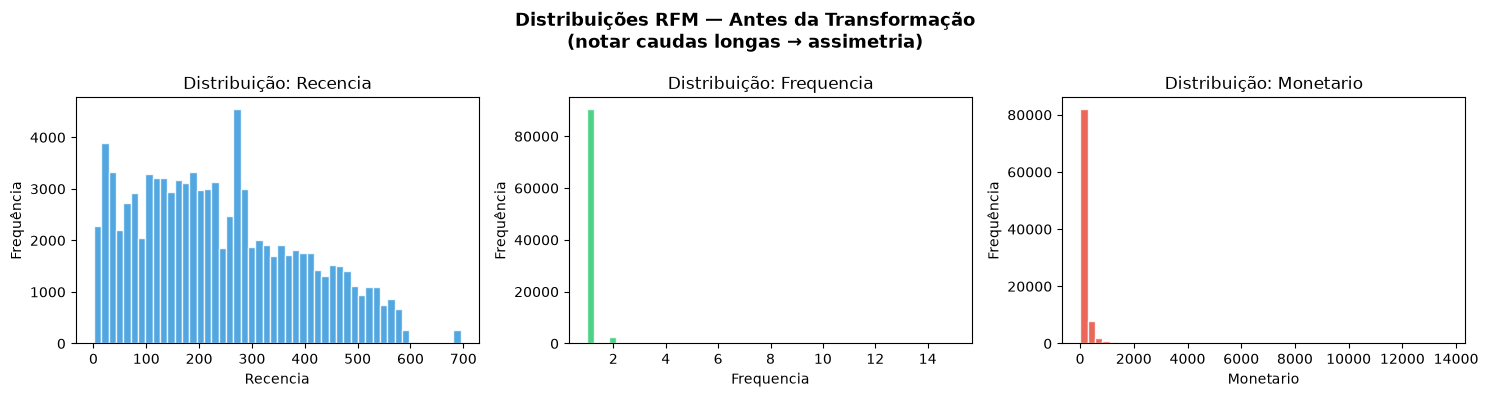

Figura salva: rfm_distribuicoes.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cores = ['#3498db', '#2ecc71', '#e74c3c']
cols  = ['Recencia', 'Frequencia', 'Monetario']

for ax, col, cor in zip(axes, cols, cores):
    ax.hist(rfm[col], bins=50, color=cor, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribuição: {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')

plt.suptitle('Distribuições RFM — Antes da Transformação\n'
             '(notar caudas longas → assimetria)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_distribuicoes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: rfm_distribuicoes.png")

#### Passo 4 — Transformação logarítmica + padronização

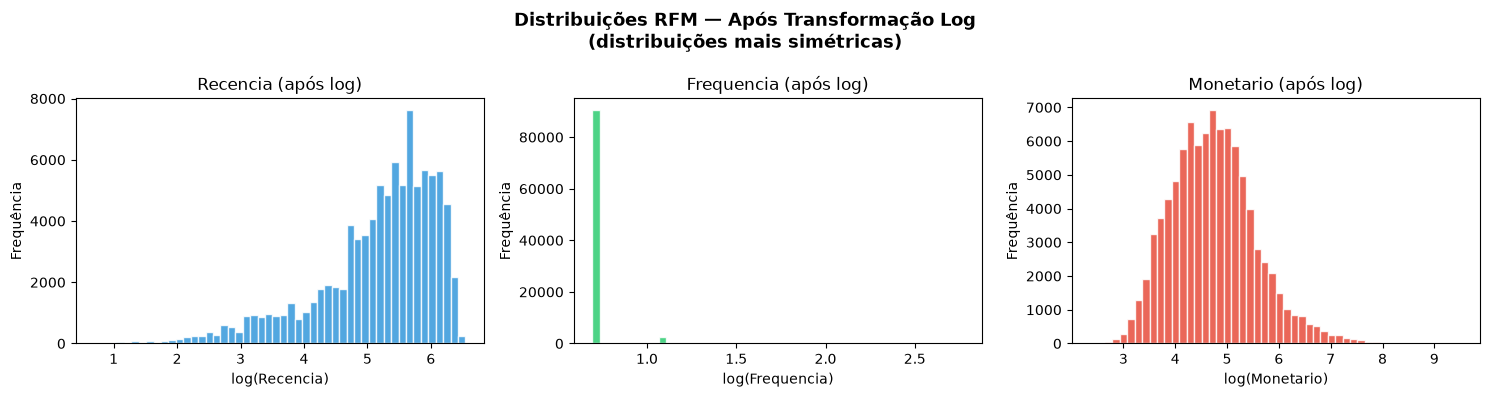

Dados prontos para clustering!
   Shape final: (93357, 3)


In [7]:
from sklearn.preprocessing import StandardScaler

# Log-transformação para corrigir assimetria
rfm_log = rfm.copy()
rfm_log['Recencia']   = np.log1p(rfm['Recencia'])
rfm_log['Frequencia'] = np.log1p(rfm['Frequencia'])
rfm_log['Monetario']  = np.log1p(rfm['Monetario'])

# Padronização
scaler_rfm = StandardScaler()
X_rfm = scaler_rfm.fit_transform(
    rfm_log[['Recencia', 'Frequencia', 'Monetario']]
)

# Mostrar distribuições após transformação
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, cor in zip(axes, cols, cores):
    ax.hist(rfm_log[col], bins=50, color=cor, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} (após log)', fontsize=12)
    ax.set_xlabel(f'log({col})')
    ax.set_ylabel('Frequência')

plt.suptitle('Distribuições RFM — Após Transformação Log\n'
             '(distribuições mais simétricas)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_distribuicoes_log.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dados prontos para clustering!")
print(f"   Shape final: {X_rfm.shape}")

#### Passo 5 — Método do Cotovelo + Silhouette para K ideal

Calculando K ideal com amostra de 5000 clientes (aguarde)...
   K=2 → Inércia: 190212.0 | Silhouette: 0.7048
   K=3 → Inércia: 129160.7 | Silhouette: 0.4167
   K=4 → Inércia: 82895.7 | Silhouette: 0.4030
   K=5 → Inércia: 68319.6 | Silhouette: 0.3580
   K=6 → Inércia: 58426.0 | Silhouette: 0.3572
   K=7 → Inércia: 51222.4 | Silhouette: 0.3535
   K=8 → Inércia: 45832.4 | Silhouette: 0.3498
   K=9 → Inércia: 41066.4 | Silhouette: 0.3491
   K=10 → Inércia: 36693.9 | Silhouette: 0.3432


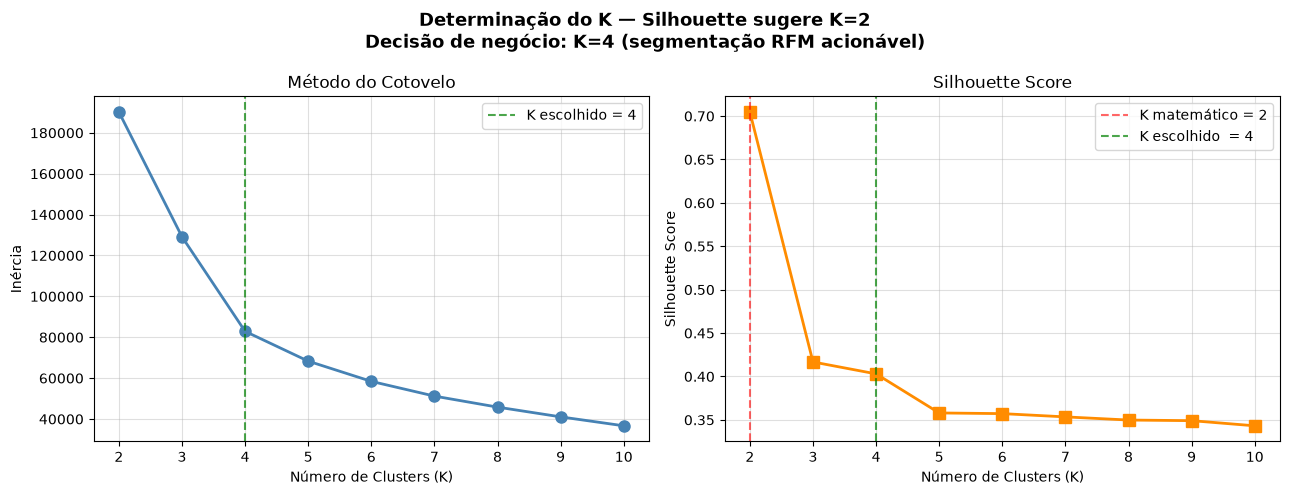


K matemático (Silhouette): 2
K escolhido  (negócio):    4


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias   = []
sil_scores = []
K_range    = range(2, 11)

AMOSTRA = 5000
np.random.seed(42)
idx_amostra = np.random.choice(len(X_rfm), size=AMOSTRA, replace=False)
X_amostra   = X_rfm[idx_amostra]

print(f"Calculando K ideal com amostra de {AMOSTRA} clientes (aguarde)...")

for k in K_range:
    km_     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_ = km_.fit_predict(X_rfm)

    labels_amostra = labels_[idx_amostra]
    sil = silhouette_score(X_amostra, labels_amostra)

    inertias.append(km_.inertia_)
    sil_scores.append(sil)
    print(f"   K={k} → Inércia: {km_.inertia_:.1f} | Silhouette: {sil:.4f}")


k_ideal     = list(K_range)[np.argmax(sil_scores)]
k_escolhido = 4

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_range, inertias, 'o-', color='steelblue', lw=2, ms=8)
axes[0].axvline(k_escolhido, color='green', ls='--', alpha=0.7,
                label=f'K escolhido = {k_escolhido}')
axes[0].set_title('Método do Cotovelo', fontsize=12)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(K_range, sil_scores, 's-', color='darkorange', lw=2, ms=8)
axes[1].axvline(k_ideal, color='red', ls='--', alpha=0.6,
                label=f'K matemático = {k_ideal}')
axes[1].axvline(k_escolhido, color='green', ls='--', alpha=0.7,
                label=f'K escolhido  = {k_escolhido}')
axes[1].set_title('Silhouette Score', fontsize=12)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('Determinação do K — Silhouette sugere K=2\n'
             'Decisão de negócio: K=4 (segmentação RFM acionável)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_k_ideal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nK matemático (Silhouette): {k_ideal}")
print(f"K escolhido  (negócio):    {k_escolhido}")

#### Passo 6 — Aplicar K-Means e nomear os segmentos

In [9]:
km_final       = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(X_rfm)

perfil = (rfm.groupby('Cluster')[['Recencia','Frequencia','Monetario']]
            .mean()
            .round(2))

print("PERFIL MÉDIO DOS CLUSTERS:")
print("=" * 55)
print(perfil)
print("=" * 55)

print(f"\nClientes por cluster:")
print(rfm['Cluster'].value_counts().sort_index())

PERFIL MÉDIO DOS CLUSTERS:
         Recencia  Frequencia  Monetario
Cluster                                 
0          272.48        1.00     295.78
1          287.33        1.00      68.21
2          220.29        2.11     308.59
3           42.02        1.00     133.91

Clientes por cluster:
Cluster
0    32185
1    42287
2     2801
3    16084
Name: count, dtype: int64


##### Interpretação dos 4 Clusters

##### Cluster 0 — Clientes em Risco

| Métrica | Valor |
|----------|--------|
| Recência Média | 272 dias |
| Frequência Média | 1,00 |
| Valor Médio | R$ 295 |
| Quantidade de Clientes | 32.185 |

**Perfil:**
- Realizaram apenas uma compra.
- Possuem ticket médio elevado.
- Não compram há bastante tempo.

**Interpretação:**
Apesar do alto valor gasto, esses clientes estão há muito tempo sem realizar novas compras, indicando risco de abandono.

**Classificação:** Em Risco

---

##### Cluster 1 — Clientes Inativos

| Métrica | Valor |
|----------|--------|
| Recência Média | 287 dias |
| Frequência Média | 1,00 |
| Valor Médio | R$ 68 |
| Quantidade de Clientes | 42.287 |

**Perfil:**
- Compraram apenas uma vez.
- Possuem baixo valor monetário.
- Estão há muito tempo sem retornar.

**Interpretação:**
Representa o maior grupo da base. São clientes com baixo engajamento e baixa contribuição financeira, possivelmente perdidos para a empresa.

**Classificação:** Inativos

---

##### Cluster 2 — Clientes Campeões

| Métrica | Valor |
|----------|--------|
| Recência Média | 220 dias |
| Frequência Média | 2,11 |
| Valor Médio | R$ 308 |
| Quantidade de Clientes | 2.801 |

**Perfil:**
- Maior frequência de compras.
- Maior valor monetário médio.
- Compram mais vezes que os demais grupos.

**Interpretação:**
Embora representem a menor parcela da base, são os clientes mais valiosos, gerando maior receita e demonstrando maior fidelidade.

**Classificação:** Campeões

---

##### Cluster 3 — Clientes Recentes

| Métrica | Valor |
|----------|--------|
| Recência Média | 42 dias |
| Frequência Média | 1,00 |
| Valor Médio | R$ 133 |
| Quantidade de Clientes | 16.084 |

**Perfil:**
- Realizaram compras recentemente.
- Ainda possuem baixa frequência de compras.
- Ticket médio intermediário.

**Interpretação:**
São clientes novos ou recentemente ativos. Possuem elevado potencial para programas de fidelização e ações de retenção.

**Classificação:** Novos/Recentes

---

##### Resumo dos Segmentos

| Cluster | Segmento | Estratégia Recomendada |
|----------|----------|------------------------|
| 0 | Em Risco | Campanhas de reativação e ofertas personalizadas |
| 1 | Inativos | Recuperação de clientes e promoções agressivas |
| 2 | Campeões | Programas VIP, recompensas e fidelização |
| 3 | Novos/Recentes | Nutrição, onboarding e incentivo à recompra |

###### Conclusão

A segmentação em 4 clusters permitiu identificar perfis distintos de clientes, possibilitando a criação de estratégias específicas para retenção, reativação e maximização do valor de cada grupo.

In [10]:
mapa_nomes = {
    0: "Em Risco",
    1: "Inativo",
    2: "Campeão",
    3: "Novo/Recente"
}

rfm['Segmento'] = rfm['Cluster'].map(mapa_nomes)

print("Segmentos atribuídos:")
print(rfm['Segmento'].value_counts())

Segmentos atribuídos:
Segmento
Inativo         42287
Em Risco        32185
Novo/Recente    16084
Campeão          2801
Name: count, dtype: int64


In [11]:
resumo = (rfm.groupby('Segmento')
             .agg(
                 Clientes   = ('customer_unique_id', 'count'),
                 Recencia_media  = ('Recencia',   'mean'),
                 Frequencia_media= ('Frequencia', 'mean'),
                 Ticket_medio    = ('Monetario',  'mean'),
                 Receita_total   = ('Monetario',  'sum')
             )
             .round(2)
             .sort_values('Receita_total', ascending=False))

print("RESUMO FINAL DOS SEGMENTOS RFM")
print("=" * 75)
print(resumo.to_string())
print("=" * 75)

RESUMO FINAL DOS SEGMENTOS RFM
              Clientes  Recencia_media  Frequencia_media  Ticket_medio  Receita_total
Segmento                                                                             
Em Risco         32185          272.48              1.00        295.78     9519736.26
Inativo          42287          287.33              1.00         68.21     2884523.47
Novo/Recente     16084           42.02              1.00        133.91     2153844.83
Campeão           2801          220.29              2.11        308.59      864357.21


#### Passo 7 — Gráficos finais de análise

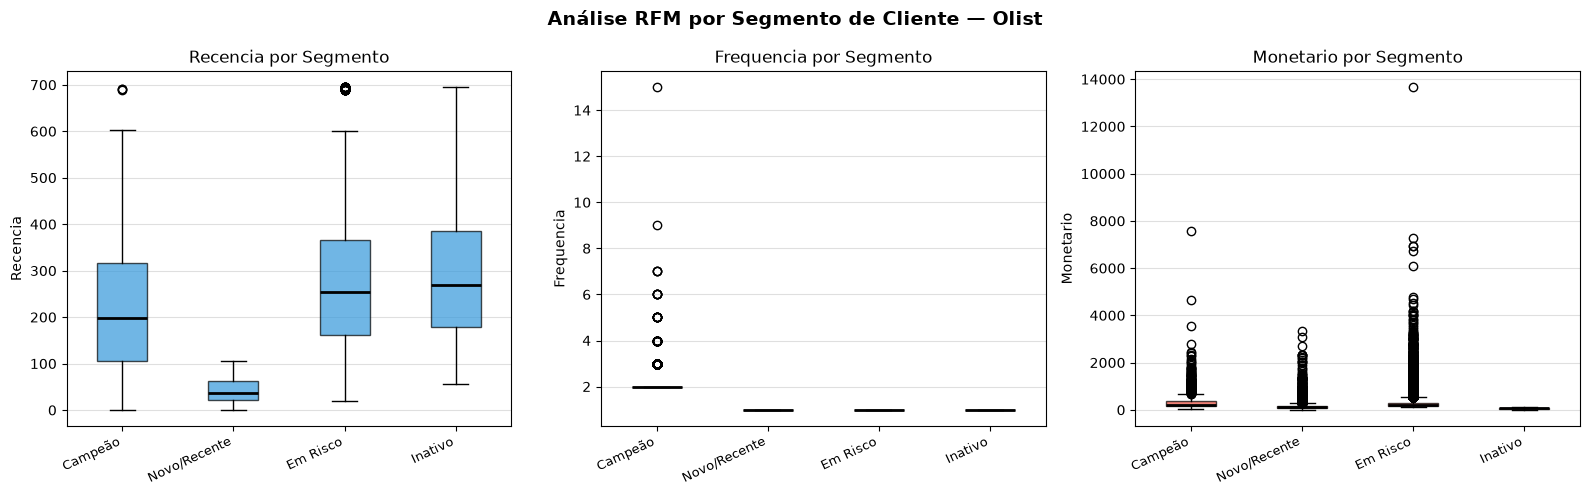

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metricas = ['Recencia', 'Frequencia', 'Monetario']
cores    = ['#3498db', '#2ecc71', '#e74c3c']
ordem    = ['Campeão', 'Novo/Recente', 'Em Risco', 'Inativo']

for ax, metrica, cor in zip(axes, metricas, cores):
    dados_plot = [rfm[rfm['Segmento'] == seg][metrica].values
                  for seg in ordem]

    bp = ax.boxplot(dados_plot, patch_artist=True,
                    medianprops=dict(color='black', lw=2))

    for patch in bp['boxes']:
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)

    ax.set_xticklabels(ordem, rotation=25, ha='right', fontsize=9)
    ax.set_title(f'{metrica} por Segmento', fontsize=12)
    ax.set_ylabel(metrica)
    ax.grid(True, axis='y', alpha=0.4)

plt.suptitle('Análise RFM por Segmento de Cliente — Olist',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_segmentos_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

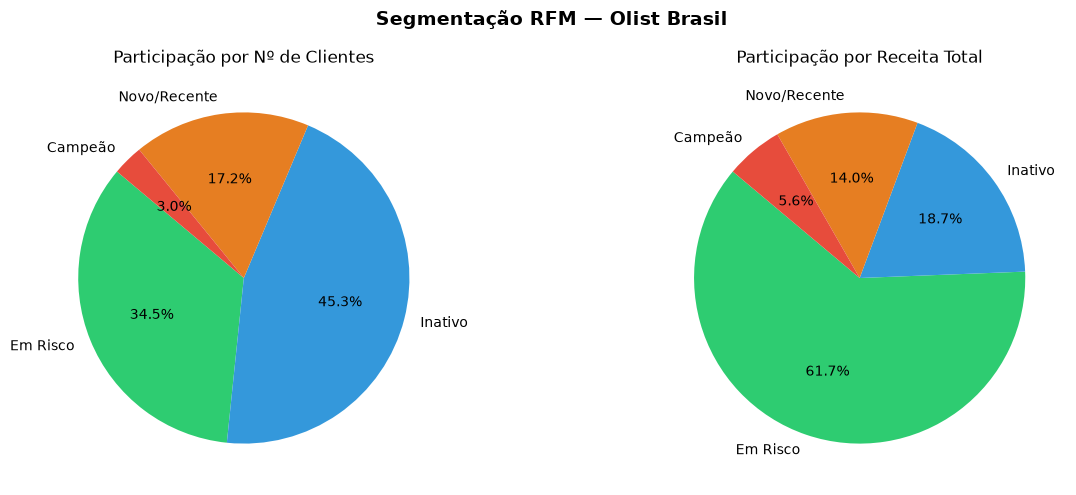


 Pipeline RFM completo!

 RECOMENDAÇÕES DE NEGÓCIO:
    Campeão     → Programa de fidelidade VIP, ofertas exclusivas
    Novo/Recente → E-mail de boas-vindas, cupom 2ª compra
    Em Risco    → Campanha de reativação, desconto especial
    Inativo     → Win-back agressivo ou aceitar perda


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cores_pizza = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

axes[0].pie(resumo['Clientes'],
            labels=resumo.index,
            autopct='%1.1f%%',
            startangle=140,
            colors=cores_pizza)
axes[0].set_title('Participação por Nº de Clientes')

axes[1].pie(resumo['Receita_total'],
            labels=resumo.index,
            autopct='%1.1f%%',
            startangle=140,
            colors=cores_pizza)
axes[1].set_title('Participação por Receita Total')

plt.suptitle('Segmentação RFM — Olist Brasil',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_pizza.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Pipeline RFM completo!")
print("\n RECOMENDAÇÕES DE NEGÓCIO:")
print("    Campeão     → Programa de fidelidade VIP, ofertas exclusivas")
print("    Novo/Recente → E-mail de boas-vindas, cupom 2ª compra")
print("    Em Risco    → Campanha de reativação, desconto especial")
print("    Inativo     → Win-back agressivo ou aceitar perda")

### Interpretação Final — Segmentação RFM Olist

##### Distribuição de Clientes e Receita

| Segmento | % de Clientes | % da Receita |
|-----------|--------------|--------------|
| Inativo | 45,3% | 18,7% |
| Em Risco | 34,5% | 61,7% |
| Novo/Recente | 17,2% | 14,0% |
| Campeão | 3,0% | 5,6% |

##### Insights Críticos

##### 1. Paradoxo do Segmento Em Risco

O segmento **Em Risco** representa apenas **34,5% dos clientes**, mas concentra **61,7% da receita total**.

Apesar da elevada contribuição financeira, esses clientes não realizam compras há aproximadamente **272 dias**, indicando um alto risco de perda de faturamento.

**Implicação de negócio:** ações de reativação direcionadas para esse grupo podem gerar grande impacto financeiro. A recuperação de uma pequena parcela desses clientes pode representar um aumento significativo na receita.

---

##### 2. Problema de Retenção

O segmento **Inativo** corresponde a **45,3% da base de clientes**, sendo o maior grupo identificado.

Características principais:

- Apenas uma compra realizada;
- Baixo valor monetário;
- Longo período sem novas compras.

Esse comportamento é comum em operações de comércio eletrônico, onde muitos clientes realizam apenas uma compra e não retornam, elevando o custo de aquisição em relação ao valor gerado ao longo do tempo.

---

##### 3. Base de Campeões Muito Pequena

O grupo **Campeão** representa apenas **3,0% dos clientes**.

Entretanto, é o segmento com:

- Maior frequência de compras;
- Maior valor médio por cliente;
- Maior potencial de fidelização.

A frequência média observada nesse grupo foi de aproximadamente **2,11 compras**, evidenciando uma oportunidade para aumentar a recorrência de compras dos demais segmentos.

---

##### 4. Janela de Oportunidade para Fidelização

Os clientes classificados como **Novos/Recentes** representam **17,2% da base** e apresentam recência média de aproximadamente **42 dias**.

Por serem os clientes mais recentemente ativos, constituem o público com maior potencial para:

- Programas de fidelidade;
- Campanhas de recompra;
- Ofertas personalizadas;
- Estratégias de relacionamento.

Investimentos nesse segmento podem aumentar significativamente a quantidade de clientes recorrentes.

---

##### Análise dos Boxplots

##### Recência

Os boxplots mostram uma separação clara do segmento **Novo/Recente**, cuja mediana de recência é significativamente menor que a dos demais grupos.

Já os segmentos **Em Risco**, **Inativo** e **Campeão** apresentam valores relativamente próximos de recência, dificultando a separação utilizando apenas essa variável.

##### Frequência

A variável frequência foi determinante para identificar o segmento **Campeão**.

Observações:

- Mediana próxima de 2 compras para Campeões;
- Presença de clientes com frequência muito superior à média;
- Demais segmentos concentrados em apenas uma compra.

Isso evidencia que a recorrência é um dos principais fatores de diferenciação dos melhores clientes.

##### Valor Monetário

A variável monetária foi essencial para distinguir os segmentos **Em Risco** e **Inativo**.

Observou-se que:

- Clientes Em Risco apresentam os maiores valores de compra e diversos outliers de alto gasto;
- Clientes Inativos possuem valores monetários significativamente menores e mais concentrados próximos de zero.

---

##### Avaliação da Clusterização com K-Means

##### Pontos Fortes

- Identificação eficiente do segmento **Novo/Recente**, devido à diferença significativa de recência.
- Separação adequada do segmento **Campeão**, impulsionada pela maior frequência de compras.
- Formação de grupos com interpretação clara para estratégias de negócio.

##### Limitações

O algoritmo apresentou maior dificuldade para distinguir os segmentos **Em Risco** e **Inativo**, pois ambos compartilham características semelhantes:

- Frequência próxima de 1 compra;
- Recência elevada (aproximadamente 272–287 dias);
- Diferença predominante apenas no valor monetário.

Como consequência, parte da separação entre esses grupos depende quase exclusivamente da variável monetária.

##### Possíveis Melhorias

Métodos alternativos podem capturar melhor as características da base de clientes, tais como:

- **DBSCAN**, para identificar grupos de densidade distinta e possíveis outliers;
- **Gaussian Mixture Models (GMM)**, para modelar distribuições mais complexas e fronteiras não lineares entre segmentos.

---

#### Conclusão Geral

A segmentação RFM utilizando **K-Means com K = 4** permitiu identificar quatro perfis distintos de clientes: **Inativos**, **Em Risco**, **Novos/Recentes** e **Campeões**.

O principal achado do estudo é que o segmento **Em Risco** concentra a maior parte da receita da empresa, embora esteja há longo período sem realizar compras. Dessa forma, estratégias de recuperação desses clientes tendem a gerar o maior retorno financeiro.

Além disso, o segmento **Novos/Recentes** representa uma importante oportunidade de fidelização, enquanto o grupo **Campeão** demonstra o perfil de comportamento que a empresa deve buscar reproduzir em uma parcela maior da base de clientes.

A análise mostra que a utilização de RFM associada ao K-Means fornece informações relevantes para direcionar ações de marketing, retenção e maximização do valor dos clientes.